<a href="https://colab.research.google.com/github/andresmidisabana/AlgNoSupervisados/blob/main/ML_Ingesta_Preparacion_Etiquetado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sección 1 — Ingesta, Preparación y Etiquetado

## 0. Imports

In [89]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.simplefilter("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

## 1. Ingesta

In [90]:
FILENAME = "logs_sanitized.log"

CANDIDATE_PATHS = [
    Path(FILENAME),
    Path("/content") / FILENAME,
    Path("/tmp") / FILENAME,
]


def load_raw_logs() -> list[str]:
    for path in CANDIDATE_PATHS:
        if path.exists():
            with open(path, "r", encoding="utf-8", errors="ignore") as f:
                lines = [ln.rstrip("\n") for ln in f if ln.strip()]
            print(f"Fuente: {path.resolve()}")
            return lines

    raise FileNotFoundError(
        f"No se encontró '{FILENAME}'. Rutas probadas:\n"
        + "\n".join(f"  - {p}" for p in CANDIDATE_PATHS)
    )


raw_logs = load_raw_logs()
print(f"Total de líneas crudas: {len(raw_logs):,}")

Fuente: /content/logs_sanitized.log
Total de líneas crudas: 9,795


## 2. Parser

In [91]:
APACHE_COMBINED_RE = re.compile(
    r'(?P<ip>\S+) \S+ \S+ '
    r'\[(?P<timestamp>[^\]]+)\] '
    r'"(?P<method>[A-Z]+) (?P<path>.*?) (?P<protocol>HTTP/\S+)" '
    r'(?P<status>\d{3}) (?P<bytes>\d+) '
    r'"(?P<referer>[^"]*)" '
    r'"(?P<user_agent>[^"]*)" '
    r'(?P<response_time>\d+)'
)


def parse_log(line: str) -> dict | None:
    m = APACHE_COMBINED_RE.match(line)
    return m.groupdict() if m else None


parsed = [parse_log(ln) for ln in raw_logs]
parsed_ok   = [p for p in parsed if p is not None]
parsed_fail = [ln for ln, p in zip(raw_logs, parsed) if p is None]

print(f"Parseadas OK        : {len(parsed_ok):,} ({len(parsed_ok)/max(len(raw_logs),1):.2%})")
print(f"Líneas no parseadas : {len(parsed_fail):,}")

df = pd.DataFrame(parsed_ok)
df.head(3)

Parseadas OK        : 9,795 (100.00%)
Líneas no parseadas : 0


,ip,timestamp,method,path,protocol,status,bytes,referer,user_agent,response_time
0,216.73.216.23,22/Apr/2026:09:17:59 +0000,GET,/sitemap.xml,HTTP/1.0,200,728,http://compromised.site/sitemap.xml,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Gecko; compatible; Claude-SearchBot/1.0; +searchbot@anthropic.com)",129405
1,170.106.181.163,22/Apr/2026:09:27:12 +0000,GET,/wp-json/oembed/1.0/embed?url=https%3A%2F%2Fcompromised.site%2Fblog%2Fpin-up-azrbaycann-n-yax-kazinosu-rsmi-sayt1069...,HTTP/1.0,200,2947,-,"Mozilla/5.0 (iPhone; CPU iPhone OS 13_2_3 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/13.0.3 Mob...",101268
2,207.180.11.159,22/Apr/2026:09:28:41 +0000,GET,/wp-json/oembed/1.0/embed?url=https%3A%2F%2Fcompromised.site%2Fprospective-families%2Ftraveling-to-camp%2F&format=xml,HTTP/1.0,200,1682,-,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36",173199


## 3. Tipado y limpieza

In [92]:
df["status"]        = pd.to_numeric(df["status"], errors="coerce").astype("Int64")
df["bytes"]         = pd.to_numeric(df["bytes"], errors="coerce").astype("Int64")
df["response_time"] = pd.to_numeric(df["response_time"], errors="coerce")
df["response_time_seconds"] = df["response_time"] / 1_000_000

df["timestamp"] = pd.to_datetime(
    df["timestamp"], format="%d/%b/%Y:%H:%M:%S %z", errors="coerce"
)

df["referer"] = df["referer"].replace({"-": pd.NA, "": pd.NA})

before = len(df)
df = df.dropna(subset=["ip", "method", "path", "status", "timestamp"]).reset_index(drop=True)
print(f"Filas eliminadas por nulos críticos: {before - len(df)}")
print(f"Filas finales: {len(df):,}")

Filas eliminadas por nulos críticos: 0
Filas finales: 9,795


## 4. Variables derivadas

In [93]:
df["hour"]           = df["timestamp"].dt.hour
df["dayofweek"]      = df["timestamp"].dt.dayofweek
df["minute"]         = df["timestamp"].dt.minute

df["path_length"]    = df["path"].str.len()
df["path_n_slashes"] = df["path"].str.count("/")
df["has_query"]      = df["path"].str.contains(r"\?", regex=True).astype(int)
df["query_length"]   = df["path"].str.split("?").str[1].fillna("").str.len()
df["path_n_pct"]     = df["path"].str.count("%")

df[[
    "hour", "dayofweek", "path_length", "path_n_slashes",
    "has_query", "query_length", "path_n_pct"
]].describe().round(2)

,hour,dayofweek,path_length,path_n_slashes,has_query,query_length,path_n_pct
count,9795.00,9795.00,9795.00,9795.00,9795.00,9795.00,9795.00
mean,12.10,2.96,44.28,3.17,0.25,17.25,1.10
std,7.57,2.24,38.80,2.35,0.43,37.09,4.36
min,0.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,4.00,1.00,13.00,1.00,0.00,0.00,0.00
50%,14.00,3.00,26.00,2.00,0.00,0.00,0.00
75%,18.00,5.00,68.00,4.00,0.00,0.00,0.00
max,23.00,6.00,631.00,10.00,1.00,605.00,159.00


## 5. Etiquetado heurístico

In [94]:
# === Detectores MITRE ATT&CK ===

# T1505.003 — Server Software Component: Web Shell
WEB_SHELL_RE = re.compile(
    r"(?i)/(c99|r57|wso|b374k|webshell|cmd|shell|hax|adminer)\.(php|aspx?|jspx?)\b"
)

# T1059 — Command and Scripting Interpreter (RCE / cmd injection)
RCE_RE = re.compile(
    r"(?i)(\beval\(|base64_decode\(|shell_exec\(|passthru\(|system\(|`[^`]+`|"
    r";\s*(cat|ls|wget|curl|nc|sh|bash)\b|<\?php|php://(input|filter))"
)

# T1190 — Exploit Public-Facing Application: SQL Injection
SQLI_RE = re.compile(
    r"(?i)(union\s+select|union\s+all\s+select|select\s+.*\s+from\s|"
    r"or\s+1\s*=\s*1|or\s+'1'\s*=\s*'1|sleep\s*\(\s*\d|benchmark\s*\(|"
    r"waitfor\s+delay|extractvalue\s*\(|xp_cmdshell|information_schema)"
)

# T1190 — Exploit Public-Facing Application: XSS
XSS_RE = re.compile(
    r"(?i)(<\s*script|javascript\s*:|onerror\s*=|onload\s*=|"
    r"<\s*svg[^>]*on|<\s*img[^>]*onerror|alert\s*\(|prompt\s*\(|document\.cookie)"
)

# T1083 — File and Directory Discovery (Path Traversal)
PATH_TRAVERSAL_RE = re.compile(
    r"(\.\./|\.\.\\|%2e%2e|%252e|/etc/passwd|/proc/self|/windows/win\.ini|/boot\.ini)"
)

# T1595 — Active Scanning: sondeo de archivos sensibles
SENSITIVE_FILE_RE = re.compile(
    r"(?i)(/\.env(\b|/)|/\.git/|/\.aws/|/\.ssh/|"
    r"wp-config\.php\.(bak|old|swp|save)|/phpinfo|/info\.php|"
    r"backup\.sql|dump\.sql|database\.sql)"
)

# T1110.001 — Brute Force: Password Guessing
LOGIN_PATHS_RE = re.compile(r"^/(wp-login\.php|admin)(\b|/|\?)", re.IGNORECASE)

# T1110.001 / T1499.001 — XMLRPC abuse (brute force amplification / DoS)
XMLRPC_RE = re.compile(r"(?i)/xmlrpc\.php")

# T1595.002 — Active Scanning: Vulnerability Scanning (UAs de escáneres)
SCANNER_UA_RE = re.compile(
    r"(?i)\b(nikto|sqlmap|nmap|wpscan|dirb|gobuster|ffuf|masscan|"
    r"nuclei|acunetix|burp|whatweb|zmap|zgrab|hydra|wfuzz)\b"
)

# T1595.002 — Active Scanning: descubrimiento de panel admin sin autenticar
ADMIN_PATH_RE = re.compile(
    r"(?i)^/(wp-admin/?|wp-login\.php|admin/?)($|\?)|^/wp-admin/[a-z0-9_\-/]+\.php"
)

# T1565.002 — Data Manipulation: SEO spam injection vía buscador WP
SPAM_SEARCH_RE = re.compile(r"^/\?(s|action)=", re.IGNORECASE)
BROKEN_UA_RE   = re.compile(r"^User-Agent:", re.IGNORECASE)

# Tráfico legítimo (no atacante)
OEMBED_PATH_RE = re.compile(r"/wp-json/oembed/", re.IGNORECASE)
WP_INTERNAL_RE = re.compile(r"^WordPress/", re.IGNORECASE)
WP_MGMT_AGENTS = re.compile(r"\b(ManageWP|iThemes-Sync|MainWP|WP\s*Remote)\b", re.IGNORECASE)
BOT_KEYWORDS   = re.compile(
    r"\b(bot|crawler|spider|searchbot|petalbot|sogou|googlebot|bingbot|"
    r"amzn|yandex|webindexer|indexer|facebook)",
    re.IGNORECASE,
)


# === Mapeo label -> MITRE para reporte ===
MITRE_TECHNIQUES = {
    # Ataques (mitre_id, descripción)
    "web_shell_access":      ("T1505.003", "Server Software Component: Web Shell"),
    "rce_command_injection": ("T1059",     "Command and Scripting Interpreter"),
    "sql_injection":         ("T1190",     "Exploit Public-Facing App: SQLi"),
    "xss_attempt":           ("T1190",     "Exploit Public-Facing App: XSS"),
    "path_traversal":        ("T1083",     "File and Directory Discovery"),
    "sensitive_file_probe":  ("T1595",     "Active Scanning: archivos sensibles"),
    "auth_brute_force":      ("T1110.001", "Brute Force: Password Guessing"),
    "xmlrpc_abuse":          ("T1110.001", "Brute Force / DoS vía XMLRPC"),
    "scanner_ua":            ("T1595.002", "Active Scanning: Vulnerability Scanning"),
    "recon_admin_probe":     ("T1595.002", "Active Scanning: Admin Discovery"),
    "seo_spam_injection":    ("T1565.002", "Data Manipulation: SEO spam"),
    # No-ataque
    "oembed_request":        (None, "WordPress oEmbed API"),
    "wp_management":         (None, "WordPress Management Tool"),
    "wp_internal":           (None, "WordPress Internal Request"),
    "search_bot":            (None, "Search Engine Crawler"),
    "legitimate_user":       (None, "Tráfico humano normal"),
}


def label_log(row) -> str:
    path   = str(row["path"])
    ua     = str(row["user_agent"])
    method = str(row["method"])
    pct    = int(row["path_n_pct"])
    try:
        status = int(row["status"])
    except (TypeError, ValueError):
        status = 0

    # === Ataques: orden de mayor a menor severidad ===
    if WEB_SHELL_RE.search(path):                                    return "web_shell_access"
    if RCE_RE.search(path):                                          return "rce_command_injection"
    if SQLI_RE.search(path):                                         return "sql_injection"
    if XSS_RE.search(path):                                          return "xss_attempt"
    if PATH_TRAVERSAL_RE.search(path):                               return "path_traversal"
    if SENSITIVE_FILE_RE.search(path):                               return "sensitive_file_probe"
    if method == "POST" and LOGIN_PATHS_RE.search(path):             return "auth_brute_force"
    if XMLRPC_RE.search(path):                                       return "xmlrpc_abuse"
    if SCANNER_UA_RE.search(ua):                                     return "scanner_ua"
    if method == "GET" and status in (301, 302) and ADMIN_PATH_RE.search(path):
        return "recon_admin_probe"
    if SPAM_SEARCH_RE.search(path) and pct >= 5:                     return "seo_spam_injection"
    if BROKEN_UA_RE.search(ua):                                      return "seo_spam_injection"

    # === Tráfico no-ataque ===
    if OEMBED_PATH_RE.search(path):                                  return "oembed_request"
    if WP_MGMT_AGENTS.search(ua):                                    return "wp_management"
    if WP_INTERNAL_RE.search(ua):                                    return "wp_internal"
    if BOT_KEYWORDS.search(ua):                                      return "search_bot"
    return "legitimate_user"


df["label"] = df.apply(label_log, axis=1)

# Resumen con técnica MITRE
summary = (
    df["label"].value_counts()
    .rename_axis("label").reset_index(name="count")
)
summary["mitre"]     = summary["label"].map(lambda l: MITRE_TECHNIQUES[l][0] or "—")
summary["technique"] = summary["label"].map(lambda l: MITRE_TECHNIQUES[l][1])
summary["is_attack"] = summary["mitre"] != "—"
summary[["label", "count", "mitre", "technique", "is_attack"]]

,label,count,mitre,technique,is_attack
0,legitimate_user,3905,—,Tráfico humano normal,False
1,auth_brute_force,1746,T1110.001,Brute Force: Password Guessing,True
2,search_bot,1248,—,Search Engine Crawler,False
3,oembed_request,1094,—,WordPress oEmbed API,False
4,recon_admin_probe,1085,T1595.002,Active Scanning: Admin Discovery,True
5,seo_spam_injection,457,T1565.002,Data Manipulation: SEO spam,True
6,wp_internal,239,—,WordPress Internal Request,False
7,wp_management,21,—,WordPress Management Tool,False


In [95]:
ATTACK_LABELS = {lbl for lbl, (mitre, _) in MITRE_TECHNIQUES.items() if mitre is not None}
df["is_attack"] = df["label"].isin(ATTACK_LABELS)

print("Distribución binaria:")
print(df["is_attack"].value_counts())
print(f"\n% de ataques: {df['is_attack'].mean() * 100:.2f}%")

print("\nClases agrupadas por is_attack:")
print(df.groupby("is_attack")["label"].value_counts())

Distribución binaria:
is_attack
False    6507
True     3288
Name: count, dtype: int64

% de ataques: 33.57%

Clases agrupadas por is_attack:
is_attack  label             
False      legitimate_user       3905
           search_bot            1248
           oembed_request        1094
           wp_internal            239
           wp_management           21
True       auth_brute_force      1746
           recon_admin_probe     1085
           seo_spam_injection     457
Name: count, dtype: int64


## 6. EDA

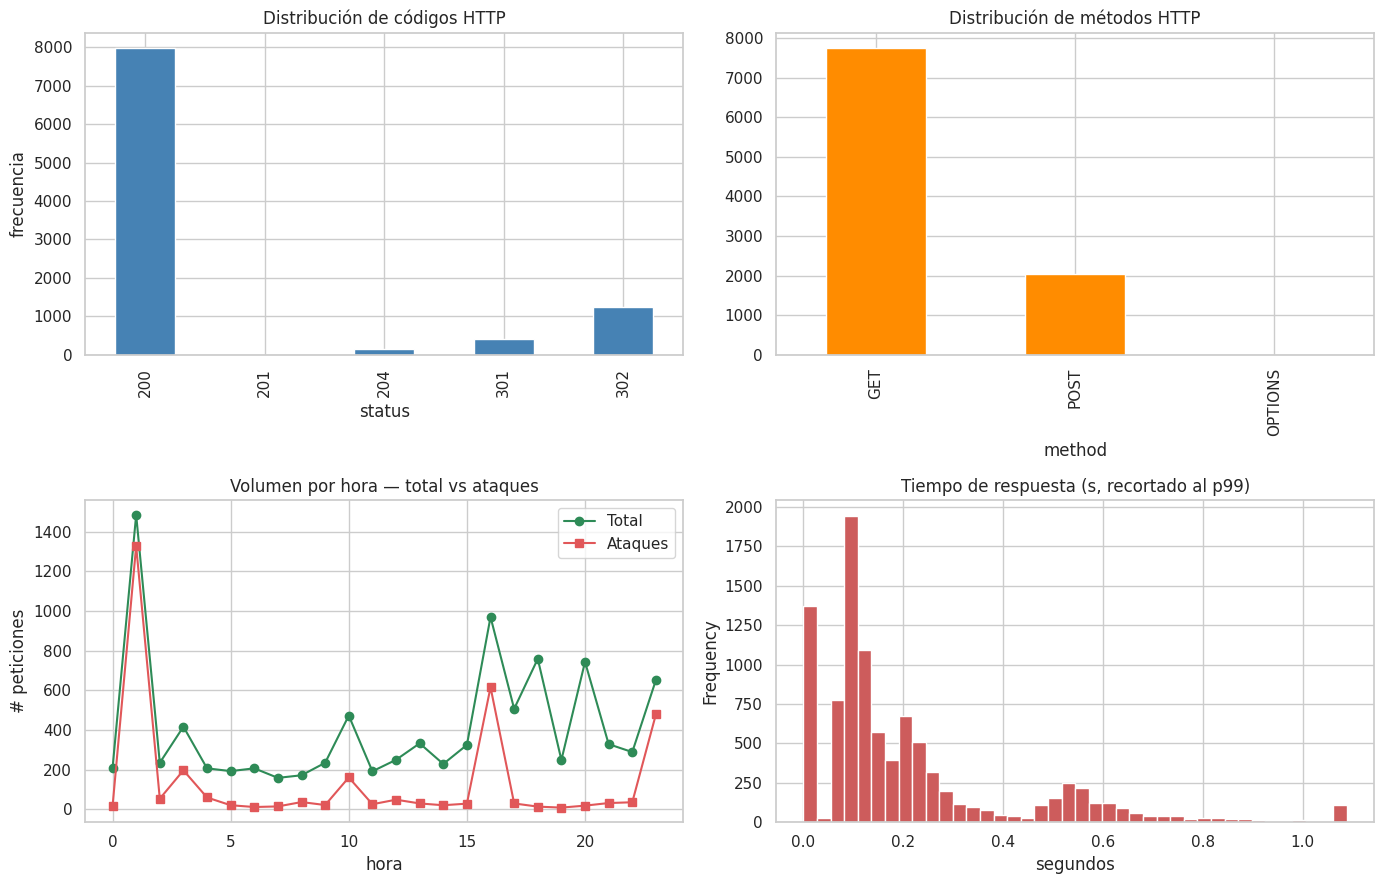

In [96]:
# Distribuciones generales + ataques en el tiempo
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

df["status"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Distribución de códigos HTTP"); axes[0, 0].set_xlabel("status"); axes[0, 0].set_ylabel("frecuencia")

df["method"].value_counts().plot(kind="bar", ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Distribución de métodos HTTP")

# Hora del día con overlay de ataques
hourly_total  = df.groupby("hour").size()
hourly_attack = df[df["is_attack"]].groupby("hour").size().reindex(hourly_total.index, fill_value=0)
hourly_total.plot(kind="line", ax=axes[1, 0], marker="o", color="seagreen", label="Total")
hourly_attack.plot(kind="line", ax=axes[1, 0], marker="s", color="#e15759", label="Ataques")
axes[1, 0].set_title("Volumen por hora — total vs ataques")
axes[1, 0].set_xlabel("hora"); axes[1, 0].set_ylabel("# peticiones"); axes[1, 0].legend()

df["response_time_seconds"].clip(upper=df["response_time_seconds"].quantile(0.99)).plot(
    kind="hist", bins=40, ax=axes[1, 1], color="indianred"
)
axes[1, 1].set_title("Tiempo de respuesta (s, recortado al p99)"); axes[1, 1].set_xlabel("segundos")

plt.tight_layout()
plt.show()

In [97]:
print("Top 10 user-agents:")
print(df["user_agent"].value_counts().head(10).to_string())
print()
print("Top 10 paths:")
print(df["path"].value_counts().head(10).to_string())

Top 10 user-agents:
user_agent
Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36                                                                    1313
Mozilla/5.0 (Linux; Android 7.0;) AppleWebKit/537.36 (HTML, like Gecko) Mobile Safari/537.36 (compatible; PetalBot;+https://webmaster.petalsearch.com/site/petalbot)      952
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36                                                     801
Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Gecko; compatible; Amzn-SearchBot/0.1) Chrome/119.0.6045.214 Safari/537.36                                                    557
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/143.0.0.0 Safari/537.36                                                           463
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/26

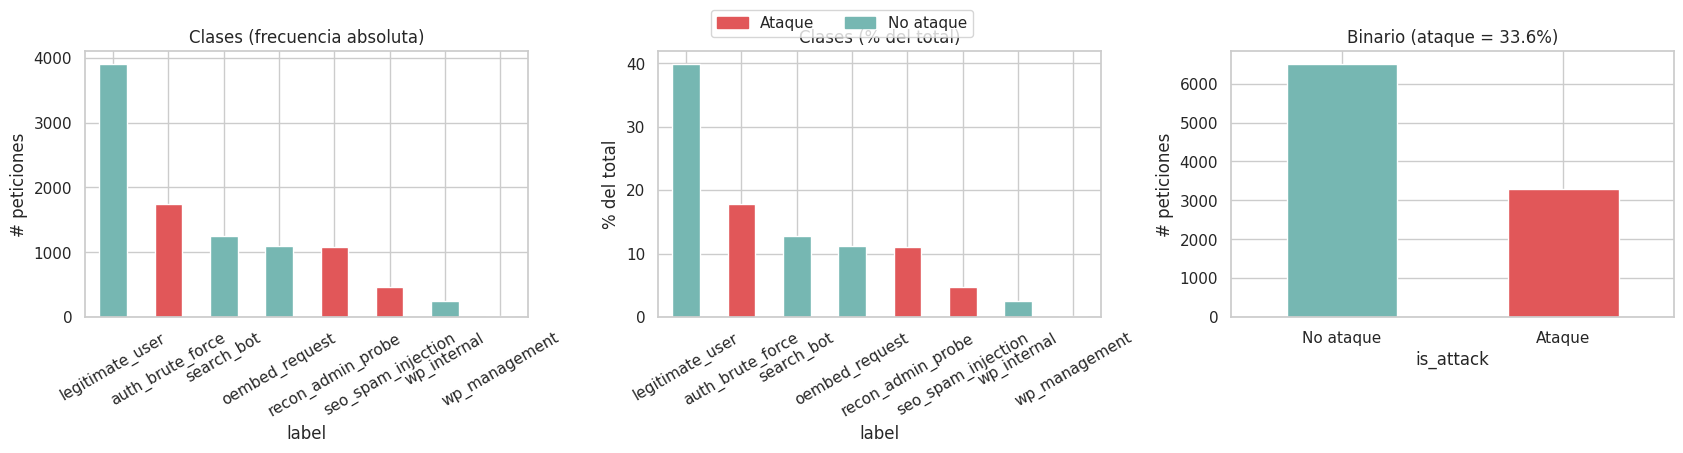

Desbalance multiclase (mayoría / minoría): 186.0x
Desbalance binario  (mayoría / minoría): 2.0x


In [98]:
ATTACK_COLOR     = "#e15759"
NON_ATTACK_COLOR = "#76b7b2"

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

counts = df["label"].value_counts()
colors = [ATTACK_COLOR if lbl in ATTACK_LABELS else NON_ATTACK_COLOR for lbl in counts.index]

# 1. Multiclase, frecuencia absoluta
counts.plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Clases (frecuencia absoluta)")
axes[0].set_ylabel("# peticiones"); axes[0].tick_params(axis="x", rotation=30)

# 2. Multiclase, porcentaje
(counts / counts.sum() * 100).plot(kind="bar", ax=axes[1], color=colors)
axes[1].set_title("Clases (% del total)")
axes[1].set_ylabel("% del total"); axes[1].tick_params(axis="x", rotation=30)

# 3. Binario: ataque vs no-ataque
binary_counts = df["is_attack"].value_counts().rename({True: "Ataque", False: "No ataque"})
binary_counts.plot(kind="bar", ax=axes[2], color=[NON_ATTACK_COLOR, ATTACK_COLOR])
axes[2].set_title(f"Binario (ataque = {df['is_attack'].mean()*100:.1f}%)")
axes[2].set_ylabel("# peticiones"); axes[2].tick_params(axis="x", rotation=0)

# Leyenda compartida
from matplotlib.patches import Patch
legend = [Patch(color=ATTACK_COLOR, label="Ataque"), Patch(color=NON_ATTACK_COLOR, label="No ataque")]
fig.legend(handles=legend, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

print(f"Desbalance multiclase (mayoría / minoría): {counts.max() / counts.min():.1f}x")
print(f"Desbalance binario  (mayoría / minoría): {binary_counts.max() / binary_counts.min():.1f}x")

In [99]:
for cls in counts.index:
    n = min(3, (df["label"] == cls).sum())
    sample = df[df["label"] == cls].sample(n, random_state=42)
    print(f"\n=== {cls} ({(df['label']==cls).sum()} casos) ===")
    print(sample[["method", "path", "status", "user_agent"]].to_string(index=False, max_colwidth=80))


=== legitimate_user (3905 casos) ===
method                                                                             path  status                                                                       user_agent
   GET                                                 /prospective-families/bunk-life/     200 Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gec...
   GET /wp-content/plugins/revslider/admin/assets/js/modules/overview.min.js?ver=6.7.14     200 Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, li...
   GET                                            /wp-admin/css/login.min.css?ver=6.9.4     200 Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, li...

=== auth_brute_force (1746 casos) ===
method          path  status                                                                       user_agent
  POST /wp-login.php     200 Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrom

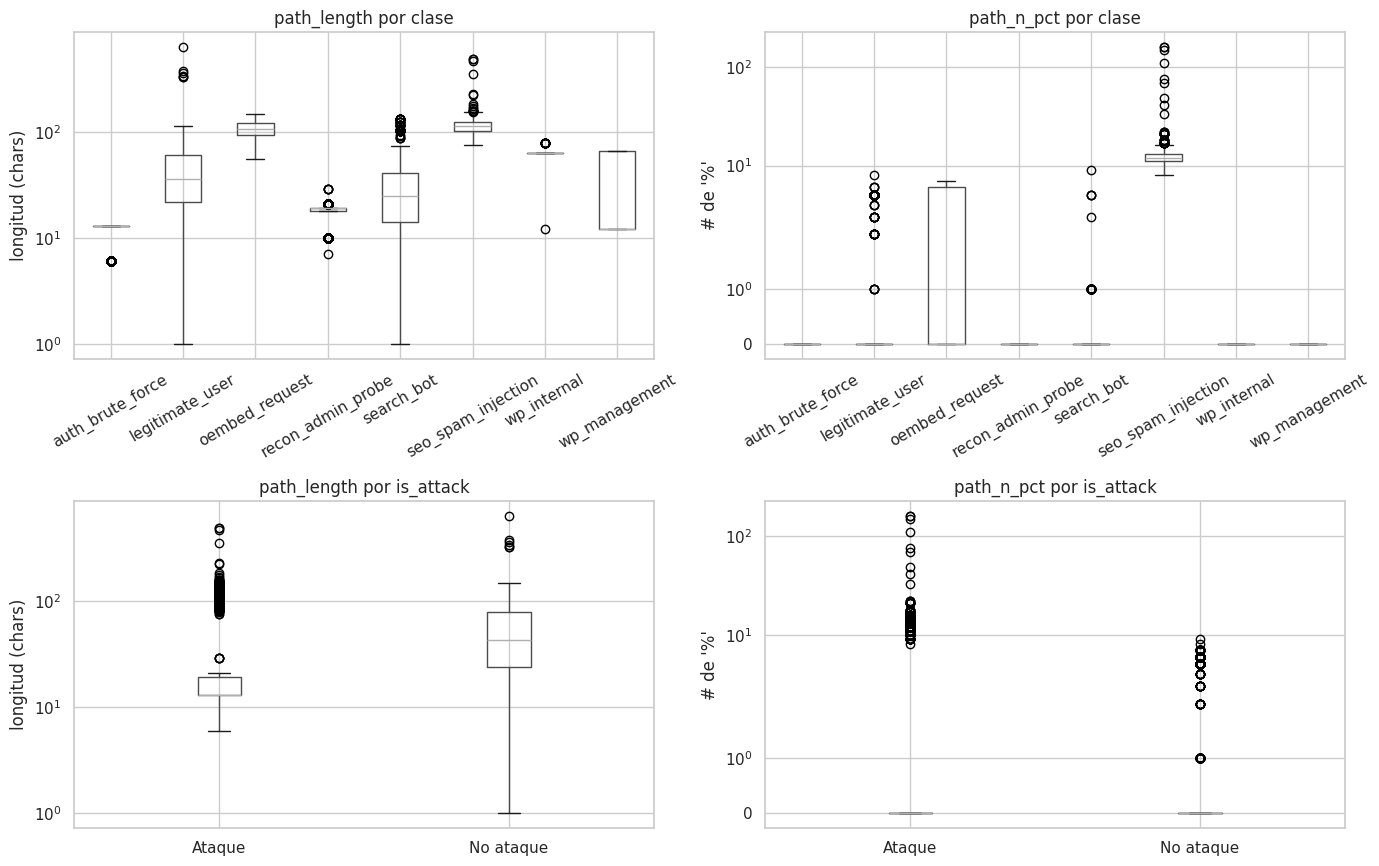

In [100]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Fila 1: por clase multiclase
df.boxplot(column="path_length", by="label", ax=axes[0, 0], rot=30)
axes[0, 0].set_title("path_length por clase"); axes[0, 0].set_xlabel(""); axes[0, 0].set_ylabel("longitud (chars)")
axes[0, 0].set_yscale("log")

df.boxplot(column="path_n_pct", by="label", ax=axes[0, 1], rot=30)
axes[0, 1].set_title("path_n_pct por clase"); axes[0, 1].set_xlabel(""); axes[0, 1].set_ylabel("# de '%'")
axes[0, 1].set_yscale("symlog")

# Fila 2: por is_attack (binario)
df_bin = df.assign(is_attack_label=df["is_attack"].map({True: "Ataque", False: "No ataque"}))

df_bin.boxplot(column="path_length", by="is_attack_label", ax=axes[1, 0])
axes[1, 0].set_title("path_length por is_attack"); axes[1, 0].set_xlabel(""); axes[1, 0].set_ylabel("longitud (chars)")
axes[1, 0].set_yscale("log")

df_bin.boxplot(column="path_n_pct", by="is_attack_label", ax=axes[1, 1])
axes[1, 1].set_title("path_n_pct por is_attack"); axes[1, 1].set_xlabel(""); axes[1, 1].set_ylabel("# de '%'")
axes[1, 1].set_yscale("symlog")

plt.suptitle("")
plt.tight_layout()
plt.show()

## 7. Guardar dataset

In [101]:
OUTPUT_CSV = Path("logs_processed.csv")
df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"Guardado: {OUTPUT_CSV.resolve()} ({OUTPUT_CSV.stat().st_size/1024:.1f} KB)")
print(f"Filas: {len(df):,} | Columnas: {df.shape[1]} | Clases: {sorted(df['label'].unique())}")

Guardado: /content/logs_processed.csv (3216.1 KB)
Filas: 9,795 | Columnas: 21 | Clases: ['auth_brute_force', 'legitimate_user', 'oembed_request', 'recon_admin_probe', 'search_bot', 'seo_spam_injection', 'wp_internal', 'wp_management']
